<a href="https://colab.research.google.com/github/Kryptera-K/BSX-Directional-Movement-Strength-CCI-Roll-Over-Strategy/blob/main/BSX.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install vectorbt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.8/527.8 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 315.5/315.5 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 25.7 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import yfinance as yf
import vectorbt as vbt

# -------------------------
# Download Data
# -------------------------

symbol = "BSX"
start_date = "2000-01-01"
end_date = "2026-01-01"
interval = "1d"

df = yf.download(symbol, start=start_date, end=end_date, interval=interval, multi_level_index=False)
df.to_csv("BSX_clean.csv", index=False)
df

/tmp/ipython-input-904792341.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(symbol, start=start_date, end=end_date, interval=interval, multi_level_index=False)
[*********************100%***********************]  1 of 1 completed


,Close,High,Low,Open,Volume
Date,,,,,
2000-01-03,11.500000,11.593750,11.000000,11.062500,4971400
2000-01-04,11.687500,12.000000,11.218750,11.437500,6709600
2000-01-05,12.531250,12.593750,11.500000,11.781250,7865600
2000-01-06,12.875000,12.937500,12.531250,12.562500,5055000
2000-01-07,12.406250,12.875000,12.250000,12.875000,6017800
...,...,...,...,...,...
2025-12-19,95.610001,97.269997,95.459999,96.849998,16423000
2025-12-22,96.430000,96.570000,95.199997,95.760002,8969200
2025-12-23,96.089996,96.250000,95.690002,95.809998,5824700


In [ ]:
# -------------------------
# Necessary Parameters
# -------------------------

ADX_LEVEL = 20
ADX_PERIOD = 14
CCI_PERIOD = 14
CCI_SHIFT = 5

# -------------------------
# Indicator Functions
# -------------------------

def adx_is_higher_than(df, period=ADX_PERIOD, level=ADX_LEVEL):
    df = calculate_adx(df, period)
    return df['ADX'] > level


def calculate_adx(df, period=14):
    """
    Calculate ADX and related columns.
    """

    # True Range (TR)
    df['H-L'] = df['High'] - df['Low']
    df['H-PC'] = abs(df['High'] - df['Close'].shift(1))
    df['L-PC'] = abs(df['Low'] - df['Close'].shift(1))
    df['TR'] = df[['H-L', 'H-PC', 'L-PC']].max(axis=1)

    # Directional Movement (DM)
    df['+DM'] = np.where((df['High'] - df['High'].shift(1)) > (df['Low'].shift(1) - df['Low']),
                         np.maximum(df['High'] - df['High'].shift(1), 0), 0)
    df['-DM'] = np.where((df['Low'].shift(1) - df['Low']) > (df['High'] - df['High'].shift(1)),
                         np.maximum(df['Low'].shift(1) - df['Low'], 0), 0)

    # Smoothed values
    df['TRn'] = df['TR'].rolling(window=period).sum()
    df['+DMn'] = df['+DM'].rolling(window=period).sum()
    df['-DMn'] = df['-DM'].rolling(window=period).sum()

    # Calculate +DI and -DI
    df['+DI'] = 100 * (df['+DMn'] / df['TRn'])
    df['-DI'] = 100 * (df['-DMn'] / df['TRn'])

    # DX and ADX
    df['DX'] = 100 * abs(df['+DI'] - df['-DI']) / (df['+DI'] + df['-DI'])
    df['ADX'] = df['DX'].rolling(window=period).mean()

    return df


def cci_falling(df, period=CCI_PERIOD, shifts=CCI_SHIFT):
    df['CCI_main'] = calculate_cci(df, period)['CCI']
    return df['CCI_main'] < df['CCI_main'].shift(shifts)


def calculate_cci(df, period=CCI_PERIOD):
    """
    Calculate Commodity Channel Index (CCI).
    """
    df = df.copy()
    # Typical Price
    df['TP'] = (df['High'] + df['Low'] + df['Close']) / 3
    # SMA of TP
    df['SMA_TP'] = df['TP'].rolling(period).mean()
    # Mean Deviation
    df['MeanDev'] = df['TP'].rolling(period).apply(
        lambda x: np.mean(np.abs(x - np.mean(x))), raw=True
    )
    # CCI
    df['CCI'] = (df['TP'] - df['SMA_TP']) / (0.015 * df['MeanDev'])
    return df



# -------------------------
# Entry conditions
# -------------------------

df["ADX_Higher20"] = adx_is_higher_than(df)

# -------------------------
# Exit conditions
# -------------------------

df["CCI_Falling"] = cci_falling(df)

# -------------------------
# Signals
# -------------------------

entry_conditions = [
    'ADX_Higher20',
]
exit_conditions = [
    'CCI_Falling',
]

df['entry_signal'] = df[entry_conditions].all(axis=1)
df['exit_signal']  = df[exit_conditions].all(axis=1)

# -------------------------
# Backtest
# -------------------------


shift_entries = df['entry_signal'].shift(1).astype(bool).fillna(False).to_numpy()
shift_exits = df['exit_signal'].shift(1).astype(bool).fillna(False).to_numpy()

pf = vbt.Portfolio.from_signals(
    close=df['Open'],
    entries=shift_entries,
    exits=shift_exits,
    init_cash=100_000,
    fees=0.001,
    slippage=0.002,
    freq='1d'
)


# -------------------------
# Portfolio Stats / Plot
# -------------------------

print(pf.stats())
pf.plot().show()

Start                                2000-01-03 00:00:00
End                                  2025-12-26 00:00:00
Period                                6536 days 00:00:00
Start Value                                     100000.0
End Value                                 1845518.626298
Total Return [%]                             1745.518626
Benchmark Return [%]                          769.062141
Max Gross Exposure [%]                             100.0
Total Fees Paid                            108583.143943
Max Drawdown [%]                               73.694528
Max Drawdown Duration                 2486 days 00:00:00
Total Trades                                         103
Total Closed Trades                                  102
Total Open Trades                                      1
Open Trade PnL                              82064.533358
Win Rate [%]                                   53.921569
Best Trade [%]                                 95.637251
Worst Trade [%]                

In [ ]:
# Buy and Hold Performance Metrics
df_holding = df['Open']
pf_holding = vbt.Portfolio.from_holding(df_holding, init_cash=100_000 , freq='D')
print(pf_holding.stats())

Start                         2000-01-03 00:00:00
End                           2025-12-26 00:00:00
Period                         6536 days 00:00:00
Start Value                              100000.0
End Value                           869062.141375
Total Return [%]                       769.062141
Benchmark Return [%]                   769.062141
Max Gross Exposure [%]                      100.0
Total Fees Paid                               0.0
Max Drawdown [%]                        89.110629
Max Drawdown Duration          4541 days 00:00:00
Total Trades                                    1
Total Closed Trades                             0
Total Open Trades                               1
Open Trade PnL                      769062.141375
Win Rate [%]                                  NaN
Best Trade [%]                                NaN
Worst Trade [%]                               NaN
Avg Winning Trade [%]                         NaN
Avg Losing Trade [%]                          NaN


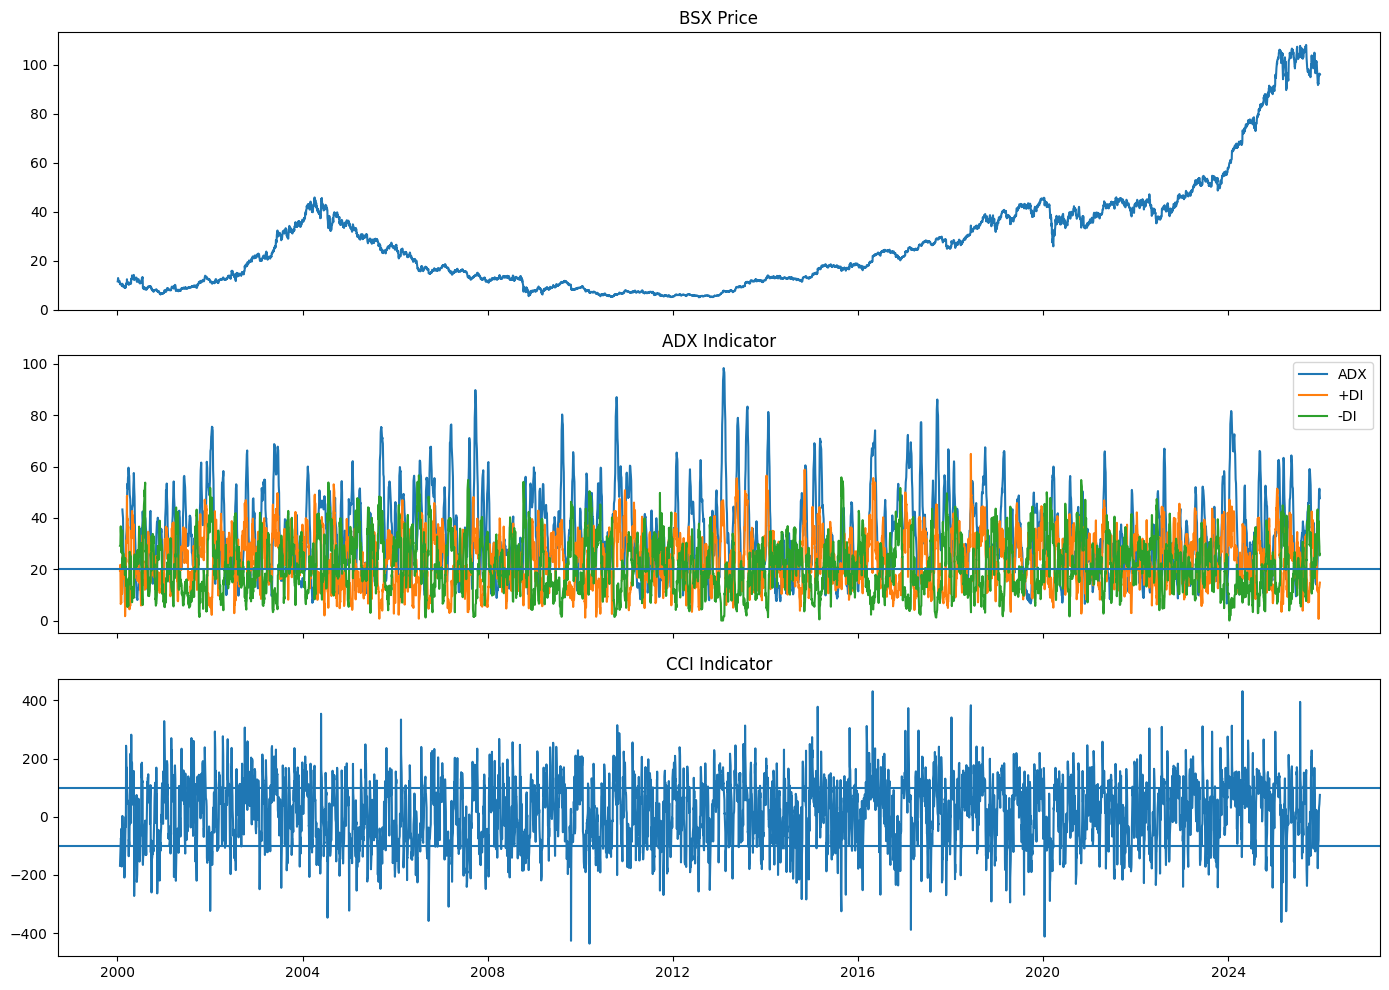

In [ ]:
import matplotlib.pyplot as plt

# -------------------------
# Plot ALL in ONE Figure
# -------------------------
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# -------------------------
# Price
# -------------------------
axes[0].plot(df.index, df['Close'])
axes[0].set_title(f"{symbol} Price")

# -------------------------
# ADX + DI
# -------------------------
axes[1].plot(df.index, df['ADX'], label='ADX')
axes[1].plot(df.index, df['+DI'], label='+DI')
axes[1].plot(df.index, df['-DI'], label='-DI')
axes[1].axhline(ADX_LEVEL)
axes[1].set_title("ADX Indicator")
axes[1].legend()

# -------------------------
# CCI
# -------------------------
axes[2].plot(df.index, df['CCI'])
axes[2].axhline(100)
axes[2].axhline(-100)
axes[2].set_title("CCI Indicator")

plt.tight_layout()
plt.show()
